データの基本情報を確認

In [3]:
import pandas as pd

# データの読み込み
df = pd.read_csv("../data/ett.csv")

# データの基本情報を表示
print("データの基本情報")
print(df.info())

# 欠損値の確認
print("\n欠損値の確認")
print(df.isnull().sum())

# 基本統計量
print("\n基本統計量")
print(df.describe())

データの基本情報
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    17420 non-null  object 
 1   HUFL    17420 non-null  float64
 2   HULL    17420 non-null  float64
 3   MUFL    17420 non-null  float64
 4   MULL    17420 non-null  float64
 5   LUFL    17420 non-null  float64
 6   LULL    17420 non-null  float64
 7   OT      17420 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.1+ MB
None

欠損値の確認
date    0
HUFL    0
HULL    0
MUFL    0
MULL    0
LUFL    0
LULL    0
OT      0
dtype: int64

基本統計量
               HUFL          HULL          MUFL          MULL          LUFL  \
count  17420.000000  17420.000000  17420.000000  17420.000000  17420.000000   
mean       7.375141      2.242242      4.300239      0.881568      3.066062   
std        7.067744      2.042342      6.826978      1.809293      1.164506   
min      -22.705999     -4.75600

時系列データの可視化

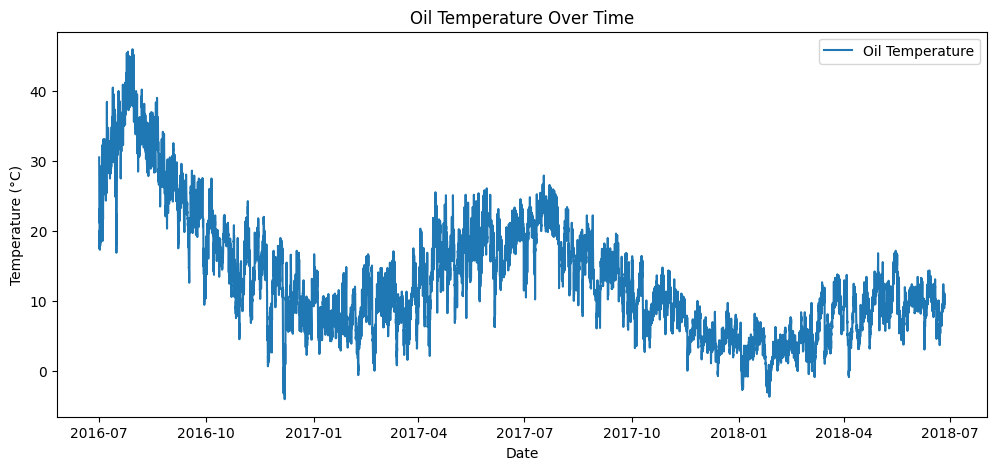

In [4]:
import matplotlib.pyplot as plt

# 日付の型変換
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# プロット
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['OT'], label="Oil Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Oil Temperature Over Time")
plt.legend()
plt.show()


1️⃣ 全体的なトレンド
2016年7月頃に急激な高温のピークが見られる。
その後、徐々に温度が低下している。
2017年後半以降、温度変動が落ち着き、安定した周期的なパターンになっている。

2️⃣ 周期性（季節性）の存在
一定の間隔で温度が上下している ことから、何かしらの周期的な要因（例：気温、負荷）が影響している可能性がある。
特に冬場に温度が下がる傾向が見られる（気温との相関があるかもしれない）。

3️⃣ 異常値（異常動作の可能性）
最初の期間（2016年7月頃）の急上昇 → 設備の調整、異常な運転、センサーの問題の可能性。
2017年後半の温度変動が小さい期間 → 運用が安定したのかもしれない。

異常値（極端に高い or 低い値）をチェックする。

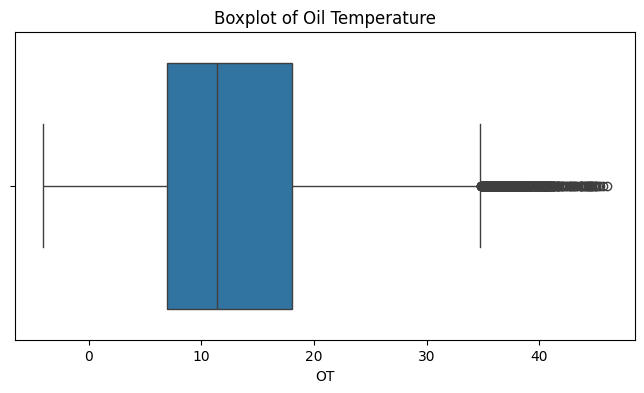

In [5]:
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.boxplot(x=df["OT"])
plt.title("Boxplot of Oil Temperature")
plt.show()


In [6]:
Q1 = df['OT'].quantile(0.25)
Q3 = df['OT'].quantile(0.75)
IQR = Q3 - Q1

# 異常値の定義（1.5IQR 以上離れているもの）
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 異常値の数をカウント
outliers = df[(df['OT'] < lower_bound) | (df['OT'] > upper_bound)]
print(f"異常値の数: {len(outliers)}")


異常値の数: 471


30℃ 以上の領域に 外れ値が多数存在している。

In [7]:
outliers = df[df["OT"] > 30]  # 30℃ 以上のデータを抽出
print(outliers)


                       HUFL   HULL   MUFL   MULL   LUFL   LULL         OT
date                                                                     
2016-07-01 00:00:00   5.827  2.009  1.599  0.462  4.203  1.340  30.531000
2016-07-03 14:00:00  10.181  5.425  7.178  3.020  3.076  1.888  30.389999
2016-07-03 15:00:00   9.645  5.425  7.107  2.665  3.015  1.828  31.164000
2016-07-03 17:00:00  11.119  5.157  7.320  2.914  3.807  1.980  32.289001
2016-07-03 18:00:00  11.052  4.957  7.391  2.523  3.686  1.980  31.938000
...                     ...    ...    ...    ...    ...    ...        ...
2016-09-03 13:00:00  10.717  5.157  7.071  2.772  2.955  1.249  30.952999
2016-09-03 14:00:00   9.578  5.090  6.929  3.696  2.772  1.340  30.108999
2016-09-03 15:00:00   8.841  5.224  6.610  3.092  2.650  1.218  30.320000
2016-09-03 16:00:00   8.774  4.890  6.396  3.696  2.619  1.218  30.812000
2016-09-03 17:00:00   9.310  4.823  6.432  3.163  2.955  1.310  30.812000

[1053 rows x 7 columns]


時間ごとの異常値分布を可視化

In [8]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ====== 1. データの読み込み ======
# データのパスを設定
file_path = "../data/ett.csv"  # 必要に応じて修正

# CSVを読み込む
df = pd.read_csv(file_path)

# datetime型に変換
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# ====== 2. スケーリング（MinMaxScalerを適用） ======
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)

# 確認
print("df_scaled を再作成しました。")
print(df_scaled.head())


df_scaled を再作成しました。
                         HUFL      HULL      MUFL      MULL      LUFL  \
date                                                                    
2016-07-01 00:00:00  0.615599  0.454943  0.628980  0.467510  0.556576   
2016-07-01 01:00:00  0.612708  0.459449  0.626458  0.464878  0.550279   
2016-07-01 02:00:00  0.601143  0.436920  0.621438  0.459689  0.512595   
2016-07-01 03:00:00  0.599698  0.450437  0.621438  0.462320  0.515693   
2016-07-01 04:00:00  0.605480  0.450437  0.626458  0.467510  0.521990   

                         LULL        OT  
date                                     
2016-07-01 00:00:00  0.613765  0.691018  
2016-07-01 01:00:00  0.620783  0.636233  
2016-07-01 02:00:00  0.586144  0.636233  
2016-07-01 03:00:00  0.599955  0.581468  
2016-07-01 04:00:00  0.599955  0.519656  


In [9]:
# IQR（四分位範囲）を計算
Q1 = df_scaled["OT"].quantile(0.25)  # 第1四分位数（25%点）
Q3 = df_scaled["OT"].quantile(0.75)  # 第3四分位数（75%点）
IQR = Q3 - Q1  # IQR（四分位範囲）

# 異常値のしきい値
lower_bound = Q1 - 1.5 * IQR  # 低すぎる値（異常値）
upper_bound = Q3 + 1.5 * IQR  # 高すぎる値（異常値）

# 異常値フラグ（1=異常値, 0=正常値）
df_scaled["outlier"] = ((df_scaled["OT"] < lower_bound) | (df_scaled["OT"] > upper_bound)).astype(int)

# **月ごとの異常値の数を集計**
monthly_outliers = df_scaled.groupby(df_scaled.index.month)["outlier"].sum()

# **異常値の数を表示**
print("月ごとの異常値の数:")
print(monthly_outliers)


月ごとの異常値の数:
date
1       0
2       0
3       0
4       0
5       0
6       0
7     337
8     134
9       0
10      0
11      0
12      0
Name: outlier, dtype: int64


曜日ごとに df_scaled を作成・スケーリングする

In [10]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ====== 1. データの読み込み ======
file_path = "../data/ett.csv"  # 必要に応じて修正
df = pd.read_csv(file_path)

# datetime型に変換
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# 曜日を追加（0=月曜, 6=日曜）
df["dayofweek"] = df.index.dayofweek  

# ====== 2. 曜日ごとにスケーリング ======
df_scaled = pd.DataFrame()  # 空のDataFrameを作成

scaler = MinMaxScaler()

# 各曜日ごとにスケーリング
for day in range(7):  # 0=月曜日, 6=日曜日
    df_day = df[df["dayofweek"] == day]  # 曜日ごとにデータを抽出
    df_day_scaled = pd.DataFrame(scaler.fit_transform(df_day.drop(columns=["dayofweek"])), 
                                 columns=df_day.columns.drop("dayofweek"), 
                                 index=df_day.index)
    df_day_scaled["dayofweek"] = day  # 曜日カラムを再追加
    df_scaled = pd.concat([df_scaled, df_day_scaled])  # 結果を結合

# 確認
print("曜日ごとにスケーリングした df_scaled を作成しました。")
print(df_scaled.head())
print(df_scaled.tail())


曜日ごとにスケーリングした df_scaled を作成しました。
                         HUFL      HULL      MUFL      MULL      LUFL  \
date                                                                    
2016-07-04 00:00:00  0.738407  0.668395  0.727931  0.557358  0.363911   
2016-07-04 01:00:00  0.715221  0.594767  0.728862  0.560495  0.345564   
2016-07-04 02:00:00  0.706941  0.584237  0.725189  0.554132  0.352927   
2016-07-04 03:00:00  0.720190  0.636807  0.710473  0.535042  0.345564   
2016-07-04 04:00:00  0.718534  0.584237  0.712309  0.547768  0.334581   

                         LULL        OT  dayofweek  
date                                                
2016-07-04 00:00:00  0.829197  0.484118          0  
2016-07-04 01:00:00  0.821190  0.567324          0  
2016-07-04 02:00:00  0.821190  0.617239          0  
2016-07-04 03:00:00  0.829197  0.618766          0  
2016-07-04 04:00:00  0.812917  0.547646          0  
                         HUFL      HULL      MUFL      MULL      LUFL  \
date       

月ごとのオイル温度分布と異常値の数を検出

c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12372 (\N{HIRAGANA LETTER GO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12458 (\N{KATAKANA LETTER O})

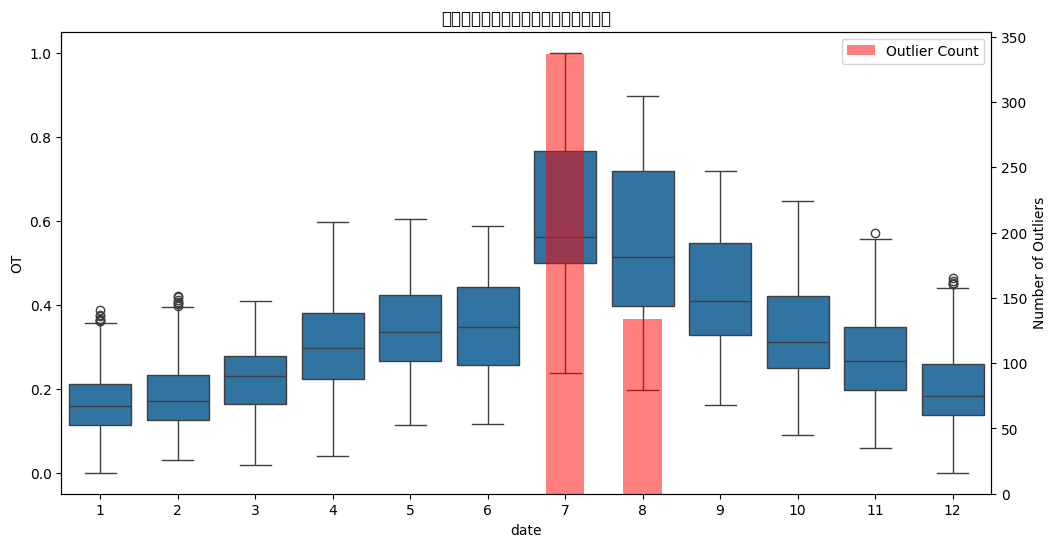

In [11]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x=df_scaled.index.month, y=df_scaled["OT"])
plt.twinx()  # 右軸を追加
monthly_outliers.plot(kind="bar", color="red", alpha=0.5, label="Outlier Count")
plt.ylabel("Number of Outliers")  # ← これが `outlier count`
plt.legend(loc="upper right")
plt.title("月ごとのオイル温度分布と異常値の数")
plt.show()


月ごとのオイル温度分布と異常値の数からわかること

(1) 7月・8月に異常値が最も多い
・異常値（outlier count）が特に7月に急増
・8月も比較的多いが、7月が特に多い
・夏季の温度変動が激しいため、異常値が増加している可能性
想定される原因:
夏の暑さによるオイル温度の急上昇（機器の冷却能力を超えた影響）
電力負荷が高まる時期（エアコンなどの需要増）
センサーの測定誤差や異常が発生しやすい環境

(2) 12月・1月にも異常値が発生
・12月・1月にも一定数の異常値が存在（赤い棒が立っている）
・箱ひげ図の外れ値 (〇) も確認できる
想定される原因:
冬季の外気温が低いため、オイル温度が通常より大きく変動
低温によるセンサー誤差や機器の影響（例: 冷却効果が通常より強くなる）
冬場の電力需要変動（暖房機器の使用増加）

➡ 異常値の発生原因が夏と冬で異なる可能性があるため、季節ごとに特徴量を作るべき！



曜日ごとの異常値を検出

時間ごとのオイル温度分布と異常値の数を可視化

時間ごとの異常値の数を計算

In [12]:
# IQR（四分位範囲）を計算
Q1 = df_scaled["OT"].quantile(0.25)  # 第1四分位数（25%点）
Q3 = df_scaled["OT"].quantile(0.75)  # 第3四分位数（75%点）
IQR = Q3 - Q1  # IQR（四分位範囲）

# 異常値のしきい値を設定
lower_bound = Q1 - 1.5 * IQR  # 低すぎる異常値
upper_bound = Q3 + 1.5 * IQR  # 高すぎる異常値

# 異常値フラグ（1=異常値, 0=正常値）
df_scaled["outlier"] = ((df_scaled["OT"] < lower_bound) | (df_scaled["OT"] > upper_bound)).astype(int)

# **時間ごとの異常値の数を集計**
hourly_outliers = df_scaled.groupby(df_scaled.index.hour)["outlier"].sum()


sns.boxplot() + twinx() で時間ごとの異常値を可視化

c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12372 (\N{HIRAGANA LETTER GO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mutow\oil_temp_forecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LE

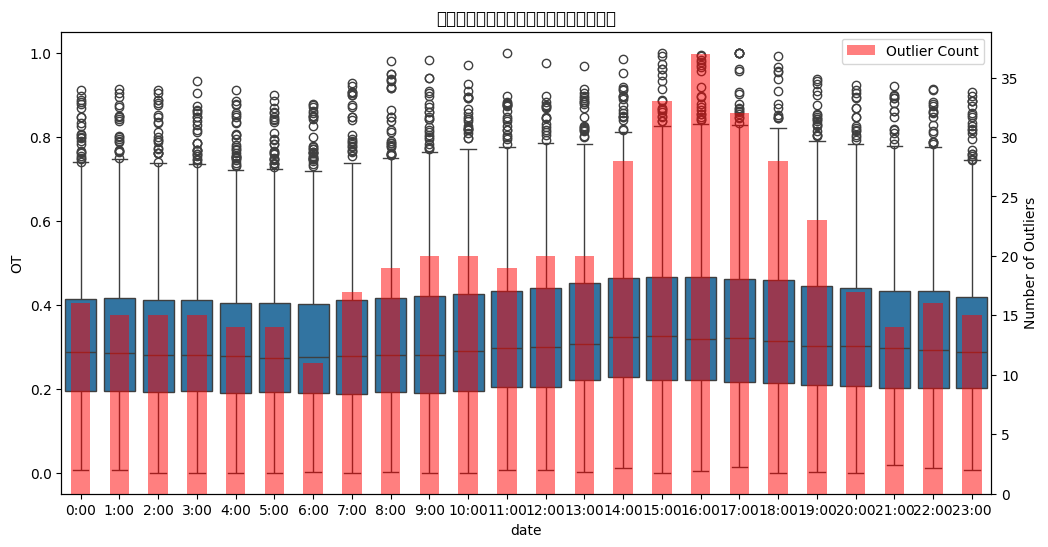

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# 時間ごとのオイル温度分布（箱ひげ図）
sns.boxplot(x=df_scaled.index.hour, y=df_scaled["OT"])

# 異常値の数を棒グラフで表示（右軸）
plt.twinx()
hourly_outliers.plot(kind="bar", color="red", alpha=0.5, label="Outlier Count")
plt.ylabel("Number of Outliers")  # 右軸のラベル
plt.legend(loc="upper right")
plt.title("時間ごとのオイル温度分布と異常値の数")

# 時間軸のラベルを修正
plt.xticks(range(24), labels=[f"{h}:00" for h in range(24)], rotation=45)

plt.show()


時間ごとのオイル温度分布と異常値の数からわかること

(1) 15時〜17時に異常値が最も多い

・異常値（outlier count）が特に16時にピーク
・15時〜17時の間に異常値が増加している

想定される原因:
15時以降、外気温がピークに達する時間帯 であり、オイル温度の急激な上昇が発生
発電機や機器の負荷が増加する時間帯 で、異常な動作が起こる可能性
夕方の電力需要の変動（工場・企業の稼働時間終了が関係？）

(2) 早朝（0時〜6時）は異常値が比較的少ない
・早朝の時間帯では、異常値（赤い棒）が低い傾向
・オイル温度の分布も安定しており、外れ値（〇）の数が比較的少ない

想定される原因:
深夜〜早朝の電力負荷が低い ため、機器の温度が安定している
外気温が低いため、オイル温度の変動が少ない
運転状態が一定 で、急激な温度変化が発生しにくい

➡ 「深夜・早朝は異常値が発生しにくい」という情報をモデルに学習させるのが有効！

(3) 昼間（9時〜14時）は異常値が増加傾向
・9時以降、異常値の発生数が増加し始める
・14時ごろにはすでに異常値が多くなっている

想定される原因:
朝の低温から昼の高温へと変化する過程で、オイル温度が急上昇する影響
太陽の影響を受けやすい機器の場合、日射量の増加とともに異常値が増える
負荷の変動が大きくなる時間帯である可能性（発電機の稼働がピークになる）

➡ 「午前〜午後にかけて異常値が増える」傾向を学習させると、予測精度が向上する可能性あり！
